In [2]:
!pip install seaborn matplotlib


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: C:\Users\adrig\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [1]:
import pandas as pd
import numpy as np
import re
import seaborn as sns
import matplotlib.pyplot as plt

# --- 1. CONFIG ---
file_paths = [
    "C:/TFG_CSIC/Outputs/IntermediateOutput-NOL_P30.csv", 
    "C:/TFG_CSIC/Outputs/IntermediateOutput-NOL_P75.csv", 
    "C:/TFG_CSIC/Outputs/IntermediateOutput-NOL_P95.csv", 
    "C:/TFG_CSIC/Outputs/IntermediateOutput-NOL_P120.csv",
    "C:/TFG_CSIC/Outputs/IntermediateOutput-NOL_P150.csv"
]
labels = ["P30", "P75", "P95", "P120", "P150"]

In [2]:
# --- 2. EXTRACTION FUNCTION (Vectorized) ---
def get_raw_data(csv_file, label):
    try:
        df = pd.read_csv(csv_file)
    except FileNotFoundError:
        print(f"File not found: {csv_file}")
        return pd.DataFrame(columns=['Mouse', 'Group', 'Session', 'DI'])

    df['Mouse'] = df['Folder'].apply(lambda x: x.split('-')[0])
    raw_results = [] # List (vector) to store the rows
    
    for mouse, group in df.groupby('Mouse'):
        group = group.copy()
        
        # Time extraction
        group['Hour'] = group['Folder'].apply(
            lambda x: int(re.search(r'-(\d{2})h', x).group(1)) if re.search(r'-(\d{2})h', x) else np.nan
        )
        group = group.sort_values(by='Hour')
        
        # Validate that it has a morning and afternoon session
        if len(group) < 2: continue
            
        morning = group.iloc[0]
        afternoon = group.iloc[-1]
        
        # Displaced object logic
        moved_DI = np.nan
        if morning['Quadrant1'] != afternoon['Quadrant1']:
            moved_DI = afternoon['Discrimination_Index_1']
        elif morning['Quadrant2'] != afternoon['Quadrant2']:
            moved_DI = afternoon['Discrimination_Index_2']
            
        # Assign Group
        mouse_group = "Unknown"
        if "Mouse4161" <= mouse <= "Mouse4170":
            mouse_group = "ChemoRescue"
        elif "Mouse4171" <= mouse <= "Mouse4180":
            mouse_group = "Chemo"
        elif "Mouse4181" <= mouse <= "Mouse4190":
            mouse_group = "Mutant"
            
        if not np.isnan(moved_DI):
            # We store as a list instead of a dictionary
            raw_results.append([mouse, mouse_group, label, moved_DI])
            
    return pd.DataFrame(raw_results, columns=['Mouse', 'Group', 'Session', 'DI'])

In [3]:
# --- 3. DATA CONSOLIDATION ---
all_data_frames = [get_raw_data(file, label) for file, label in zip(file_paths, labels)]
df_all = pd.concat(all_data_frames, ignore_index=True)

print(f"Total records initially processed: {len(df_all)}")

Total records initially processed: 143


In [4]:
print(df_all)

         Mouse        Group Session     DI
0    Mouse4161  ChemoRescue     P30  0.271
1    Mouse4162  ChemoRescue     P30  0.279
2    Mouse4163  ChemoRescue     P30 -0.587
3    Mouse4164  ChemoRescue     P30  0.206
4    Mouse4165  ChemoRescue     P30  0.218
..         ...          ...     ...    ...
138  Mouse4186       Mutant    P150  0.291
139  Mouse4187       Mutant    P150  0.232
140  Mouse4188       Mutant    P150  0.059
141  Mouse4189       Mutant    P150 -0.529
142  Mouse4190       Mutant    P150  0.190

[143 rows x 4 columns]


In [5]:
# --- 4. OUTLIER CALCULATION ---

# Method A: Global
limit_global_low = df_all['DI'].quantile(0.05)
limit_global_high = df_all['DI'].quantile(0.95)
df_all['Outlier_Global'] = (df_all['DI'] < limit_global_low) | (df_all['DI'] > limit_global_high)

# Method B: By Group (Recommended)
group_limits = df_all.groupby('Group')['DI'].quantile([0.05, 0.95]).unstack()
group_limits.columns = ['Lower', 'Upper']

def check_group_outlier(row):
    grp = row['Group']
    val = row['DI']
    if grp not in group_limits.index: return False
    return (val < group_limits.loc[grp, 'Lower']) or (val > group_limits.loc[grp, 'Upper'])

df_all['Outlier_Group'] = df_all.apply(check_group_outlier, axis=1)

# We create the clean DataFrames
df_clean_global = df_all[~df_all['Outlier_Global']]
df_clean_group = df_all[~df_all['Outlier_Group']]

In [6]:
# --- 5. CONSOLE RESULTS ---
print("\n--- Outlier Summary ---")
print(f"Global Limits: {limit_global_low:.3f} to {limit_global_high:.3f}")
print(f"Videos removed (Global): {df_all['Outlier_Global'].sum()}")
print(f"Total clean records (Global): {len(df_clean_global)}")
print(f"Videos removed (By Group): {df_all['Outlier_Group'].sum()}")
print(f"Total clean records (By Group): {len(df_clean_group)}")
print(f"Total: {len(df_all)}")

print("\nExample of videos detected as outliers (By Group):")
print(df_all[df_all['Outlier_Group']][['Mouse', 'Session', 'Group', 'DI']].head())


--- Outlier Summary ---
Global Limits: -0.420 to 0.501
Videos removed (Global): 16
Total clean records (Global): 127
Videos removed (By Group): 18
Total clean records (By Group): 125
Total: 143

Example of videos detected as outliers (By Group):
        Mouse Session        Group     DI
2   Mouse4163     P30  ChemoRescue -0.587
8   Mouse4169     P30  ChemoRescue -0.547
13  Mouse4174     P30        Chemo -0.360
16  Mouse4177     P30        Chemo -0.424
22  Mouse4183     P30       Mutant  0.502


In [7]:
# --- 6. DATA VISUALIZATION (AESTHETICS AND EXACT COLORS) ---

import seaborn as sns
import matplotlib.pyplot as plt

# Your exact colors for the groups
colores_grupos = {
    "ChemoRescue": 'purple', 
    "Chemo": 'pink', 
    "Mutant": 'green'
}

sesiones_orden = ["P30", "P75", "P95", "P120", "P150"]
grupos_orden = ["ChemoRescue", "Chemo", "Mutant"]

sns.set_style("ticks")

# Your aesthetics block adjusted to properly handle legends
def aplicar_estetica(titulo):
    plt.axhline(y=0, color='grey', linestyle='-', alpha=0.3, linewidth=1)
    plt.ylabel("Discrimination Index")
    plt.xlabel("Session")
    plt.title(titulo, pad=15) 
    ax = plt.gca()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # We extract the legend to keep only the 3 groups (avoiding duplicates due to overlay)
    handles, labels = ax.get_legend_handles_labels()
    if len(handles) >= 3:
        plt.legend(handles[:3], labels[:3], title='Group', loc='upper left', bbox_to_anchor=(1.05, 1))
    else:
        plt.legend(loc='upper left', bbox_to_anchor=(1.05, 1))
        
    plt.tight_layout()

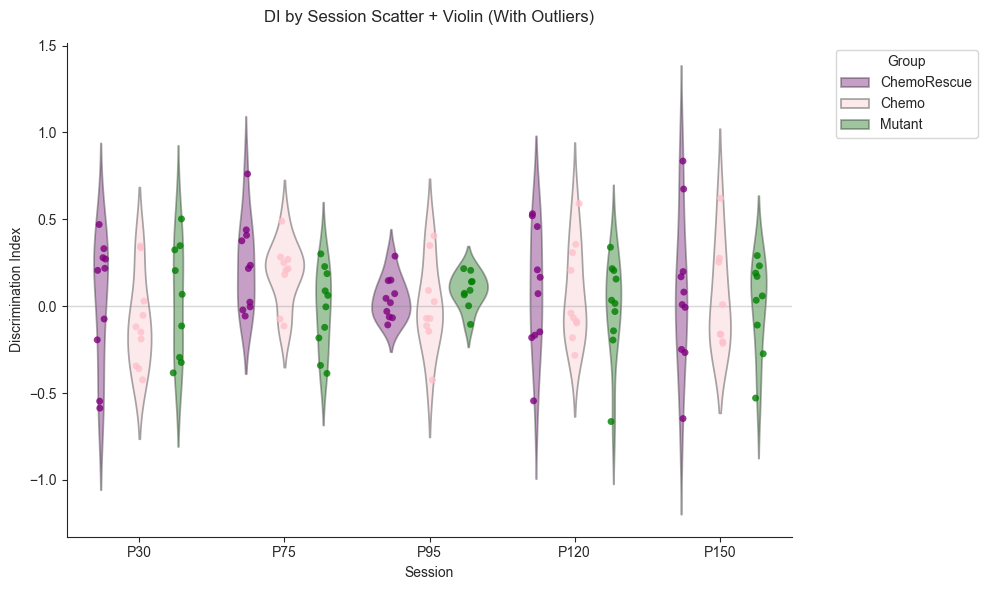

In [8]:
# -------------------------------------------------------------------------
# PLOT 1: Violin + Scatter (WITH ALL DATA / WITH OUTLIERS)
# -------------------------------------------------------------------------
plt.figure(figsize=(10, 6))

sns.violinplot(
    data=df_all, x='Session', y='DI', hue='Group', # We use df_all
    palette=colores_grupos, inner=None, alpha=0.4, order=sesiones_orden, hue_order=grupos_orden
)
sns.stripplot(
    data=df_all, x='Session', y='DI', hue='Group', 
    palette=colores_grupos, dodge=True, alpha=0.8, size=5, legend=False,
    order=sesiones_orden, hue_order=grupos_orden
)

aplicar_estetica("DI by Session Scatter + Violin (With Outliers)")
plt.show()

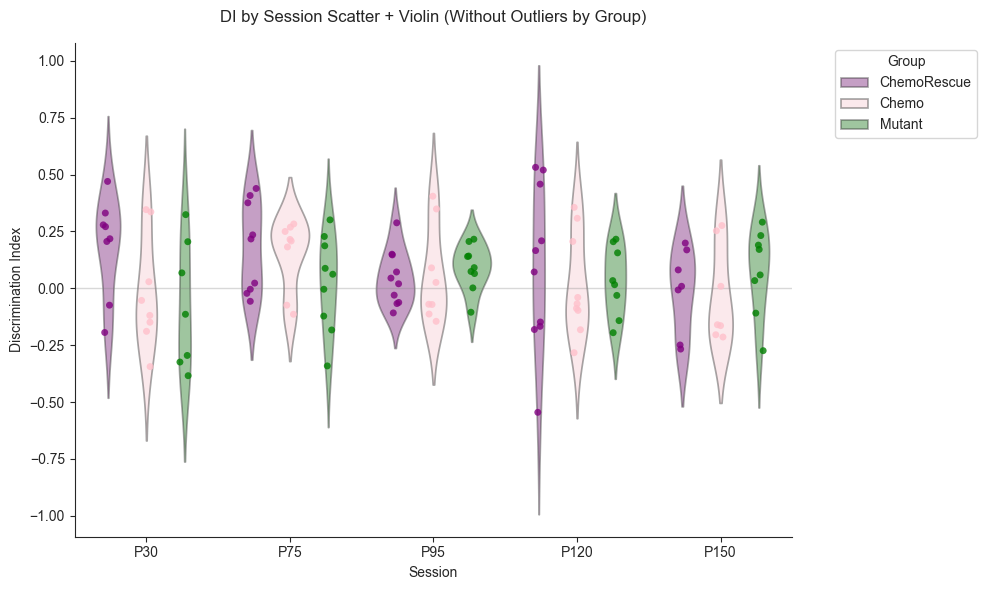

In [9]:
# -------------------------------------------------------------------------
# PLOT 2: Violin + Scatter (WITHOUT OUTLIERS BY GROUP)
# -------------------------------------------------------------------------
plt.figure(figsize=(10, 6))

sns.violinplot(
    data=df_clean_group, x='Session', y='DI', hue='Group', 
    palette=colores_grupos, inner=None, alpha=0.4, order=sesiones_orden, hue_order=grupos_orden
)
sns.stripplot(
    data=df_clean_group, x='Session', y='DI', hue='Group', 
    palette=colores_grupos, dodge=True, alpha=0.8, size=5, legend=False,
    order=sesiones_orden, hue_order=grupos_orden
)

aplicar_estetica("DI by Session Scatter + Violin (Without Outliers by Group)")
plt.show()

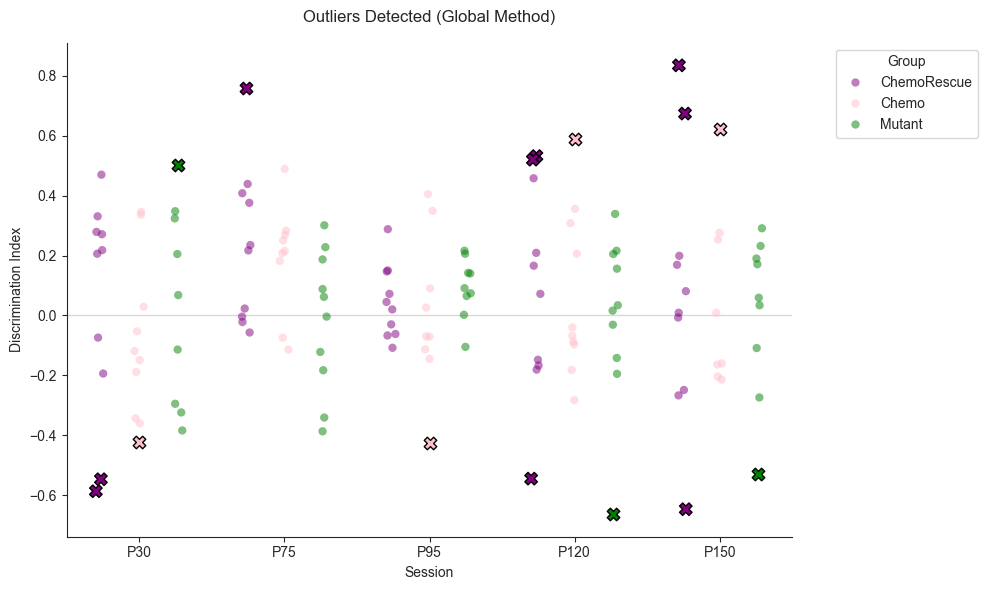

In [10]:
# -------------------------------------------------------------------------
# PLOT 3: Outliers Global Method (Circles = Normal, X = Outliers)
# -------------------------------------------------------------------------
plt.figure(figsize=(10, 6))

# 1. Plot NORMAL data (Circles)
sns.stripplot(
    data=df_all[~df_all['Outlier_Global']], x='Session', y='DI', hue='Group', 
    palette=colores_grupos, dodge=True, marker='o', alpha=0.5, size=6, 
    order=sesiones_orden, hue_order=grupos_orden
)

# 2. Plot OUTLIERS (Large Xs)
sns.stripplot(
    data=df_all[df_all['Outlier_Global']], x='Session', y='DI', hue='Group', 
    palette=colores_grupos, dodge=True, marker='X', alpha=1.0, size=9, 
    order=sesiones_orden, hue_order=grupos_orden, 
    linewidth=1, edgecolor='black'
)

aplicar_estetica("Outliers Detected (Global Method)")
plt.show()

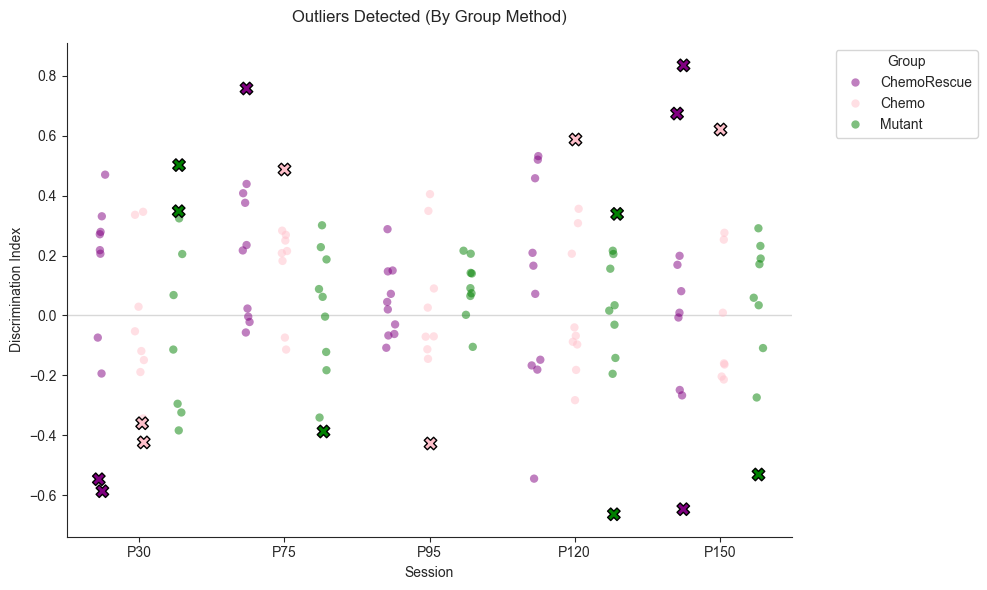

In [11]:
# -------------------------------------------------------------------------
# PLOT 4: Outliers By Group Method (Circles = Normal, X = Outliers)
# -------------------------------------------------------------------------
plt.figure(figsize=(10, 6))

# 1. Plot NORMAL data (Circles)
sns.stripplot(
    data=df_all[~df_all['Outlier_Group']], x='Session', y='DI', hue='Group', 
    palette=colores_grupos, dodge=True, marker='o', alpha=0.5, size=6, 
    order=sesiones_orden, hue_order=grupos_orden
)

# 2. Plot OUTLIERS (Large Xs)
sns.stripplot(
    data=df_all[df_all['Outlier_Group']], x='Session', y='DI', hue='Group', 
    palette=colores_grupos, dodge=True, marker='X', alpha=1.0, size=9, 
    order=sesiones_orden, hue_order=grupos_orden, 
    linewidth=1, edgecolor='black'
)

aplicar_estetica("Outliers Detected (By Group Method)")
plt.show()

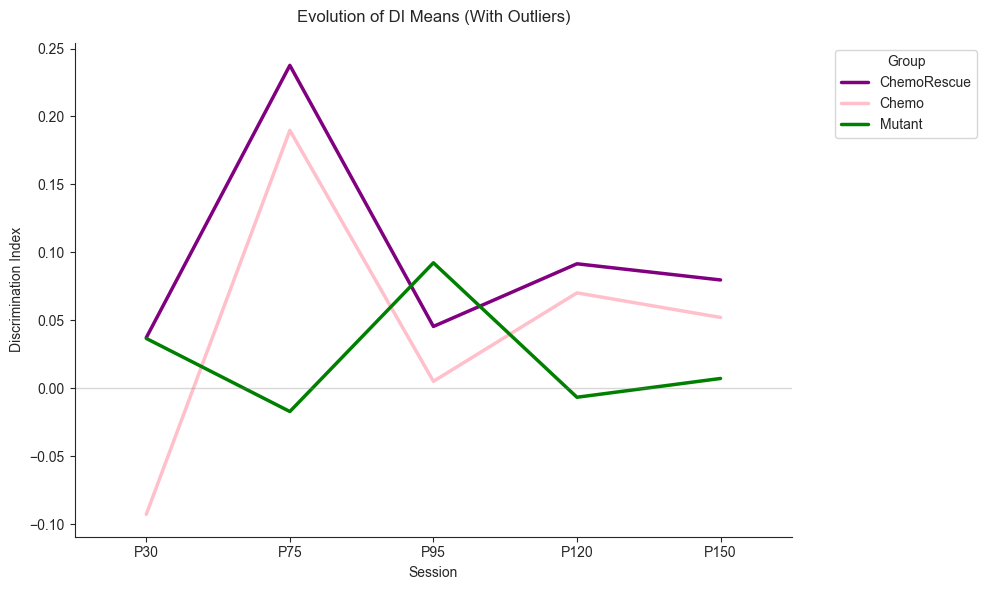

In [12]:
# -------------------------------------------------------------------------
# PLOT 5: Mean Trajectory (WITH ALL DATA / WITH OUTLIERS)
# -------------------------------------------------------------------------
plt.figure(figsize=(10, 6))
sns.pointplot(
    data=df_all, x='Session', y='DI', hue='Group', 
    markers="", # <--- We remove the markers
    errorbar=None, # <--- We remove the error bars
    linewidth=2.5, # We make the line a bit thicker so it looks good
    palette=colores_grupos, dodge=False, order=sesiones_orden, hue_order=grupos_orden
)
aplicar_estetica("Evolution of DI Means (With Outliers)")
plt.show()

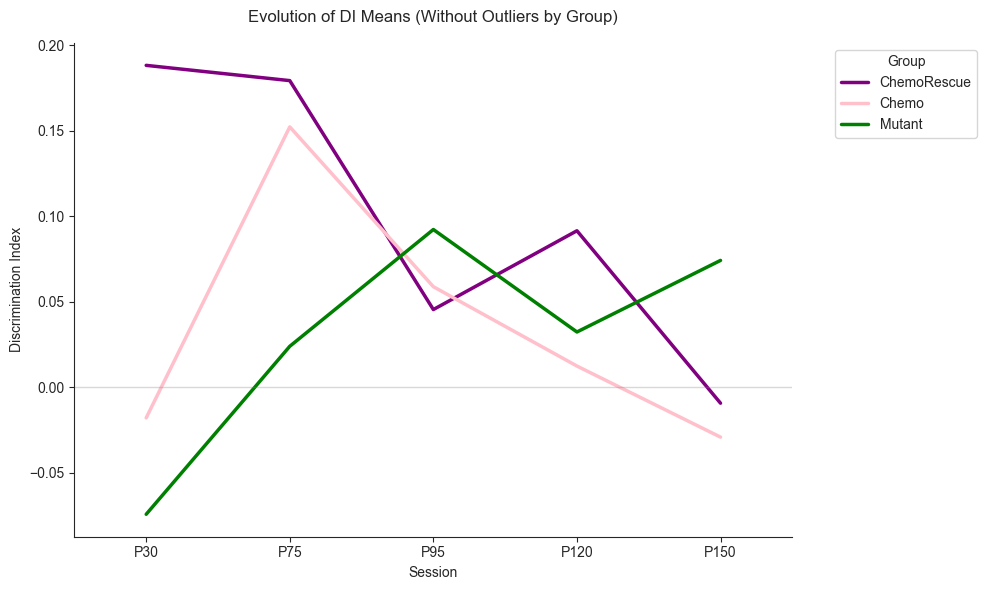

In [13]:
# -------------------------------------------------------------------------
# PLOT 6: Mean Trajectory (Mean ± SEM) (WITHOUT OUTLIERS BY GROUP)
# -------------------------------------------------------------------------
plt.figure(figsize=(10, 6))
sns.pointplot(
    data=df_clean_group, x='Session', y='DI', hue='Group', 
    markers="", # <--- We remove the markers
    errorbar=None, # <--- We remove the error bars
    linewidth=2.5,
    palette=colores_grupos, dodge=False, order=sesiones_orden, hue_order=grupos_orden
)
aplicar_estetica("Evolution of DI Means (Without Outliers by Group)")
plt.show()